# Evaluation: Reference-Based vs VLM Baseline

This notebook evaluates whether the reference-based size estimates outperform the no-reference VLM baseline.

Inputs:
- Ground truth: `data/cs543_data_collection_plan_updated.csv`
- VLM baseline JSON files: `results/vlm_baseline/*_vlm_baseline.json`
- Reference-based results: split direct-measurement CSVs matching `results/direct_measurement_output*_*.csv`

The key paired question is: for the same photo, is the reference-based error lower than the VLM baseline error?

In [22]:
from pathlib import Path
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except ImportError:
    sns = None
    warnings.warn("seaborn is not installed; plots will use default matplotlib style.")
    plt.style.use("ggplot")

try:
    from scipy import stats
except ImportError:
    stats = None
    warnings.warn("scipy is not installed; paired t-tests and Wilcoxon tests will be skipped.")

# Keep notebook tables readable when showing joined metadata and metrics.
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

# Let the notebook run from either the repository root or the notebooks/ directory.
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "data").exists() and (REPO_ROOT.parent / "data").exists():
    REPO_ROOT = REPO_ROOT.parent

GT_PATH = REPO_ROOT / "data" / "cs543_data_collection_plan_updated.csv"
BASELINE_DIR = REPO_ROOT / "results" / "vlm_baseline"
REFERENCE_GLOB = "direct_measurement_output*_*.csv"
REFERENCE_PATHS = sorted((REPO_ROOT / "results").glob(REFERENCE_GLOB))

GT_PATH, BASELINE_DIR, REFERENCE_PATHS

(PosixPath('/Users/jiachenliu/Repositories/CS543_Final_Project/data/cs543_data_collection_plan_updated.csv'),
 PosixPath('/Users/jiachenliu/Repositories/CS543_Final_Project/results/vlm_baseline'),
 [PosixPath('/Users/jiachenliu/Repositories/CS543_Final_Project/results/direct_measurement_outputs_0_40.csv'),
  PosixPath('/Users/jiachenliu/Repositories/CS543_Final_Project/results/direct_measurement_outputs_40_80.csv'),
  PosixPath('/Users/jiachenliu/Repositories/CS543_Final_Project/results/direct_measurement_outputs_80_120.csv')])

## Load and Validate Size Data

Validating data files.

In [23]:
# Fail early with clear messages if result files have not been generated yet.
def require_file(path: Path) -> None:
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")

def require_dir(path: Path) -> None:
    if not path.exists():
        raise FileNotFoundError(f"Missing required directory: {path}")

require_file(GT_PATH)
require_dir(BASELINE_DIR)

# Check that at least one reference-based estimate file exists, and that all files exist.
if len(REFERENCE_PATHS) == 0:
    raise FileNotFoundError(f"No reference-based estimate files found matching: {REFERENCE_GLOB}")
for path in REFERENCE_PATHS:
    require_file(path)

gt = pd.read_csv(GT_PATH)

# Reference-based estimates are split into multiple batch CSVs; concatenate them vertically.
reference_raw = pd.concat(
    [pd.read_csv(path, encoding="utf-8-sig").assign(source_file=path.name) for path in REFERENCE_PATHS],
    ignore_index=True,
)

print(f"Ground-truth rows: {len(gt)}")
print(f"Reference-based files: {[path.name for path in REFERENCE_PATHS]}")
print(f"Reference-based rows after concat: {len(reference_raw)}")
print(f"Baseline JSON files: {len(list(BASELINE_DIR.glob('*.json')))}")

Ground-truth rows: 120
Reference-based files: ['direct_measurement_outputs_0_40.csv', 'direct_measurement_outputs_40_80.csv', 'direct_measurement_outputs_80_120.csv']
Reference-based rows after concat: 120
Baseline JSON files: 120


Read in the ground truth and estimates, converting them to DataFrames and normalizing column.

In [24]:
def photo_id_from_baseline_path(path: Path) -> str:
    return re.sub(r"_vlm_baseline$", "", path.stem)

def orient_dimensions(length_like: float, width_like: float) -> tuple[float, float]:
    """Return dimensions as (longer_side, shorter_side)."""
    longer = max(float(length_like), float(width_like))
    shorter = min(float(length_like), float(width_like))
    return longer, shorter

def extract_length_width(payload: dict, source_path: Path) -> tuple[float, float]:
    # Read whichever dimension names are present, then normalize orientation below.
    length_keys = ["length_cm", "height_cm", "Length (cm)", "height"]
    width_keys = ["width_cm", "Width (cm)", "width"]

    length = next((payload[k] for k in length_keys if k in payload), None)
    width = next((payload[k] for k in width_keys if k in payload), None)
    if length is None or width is None:
        raise ValueError(f"Could not find length/width keys in {source_path}: {payload}")
    return orient_dimensions(length, width)

# Convert one JSON file per image into a pandas dataframe keyed by Photo ID.
baseline_rows = []
for path in sorted(BASELINE_DIR.glob("*.json")):
    with path.open("r", encoding="utf-8") as f:
        payload = json.load(f)
    length_cm, width_cm = extract_length_width(payload, path)
    baseline_rows.append({
        "Photo ID": photo_id_from_baseline_path(path),
        "baseline_length_cm": length_cm,
        "baseline_width_cm": width_cm,
        "baseline_file": str(path.relative_to(REPO_ROOT)),
    })

baseline = pd.DataFrame(baseline_rows)

# Clean reference CSVs 
reference = reference_raw.rename(columns={
    "Estimated Target Length (cm)": "reference_length_cm",
    "Estimated Target Width (cm)": "reference_width_cm",
})

if "Photo ID" not in reference.columns and "Image Filename" in reference.columns:
    reference["Photo ID"] = reference["Image Filename"].map(lambda value: Path(str(value)).stem)

required_reference_cols = {"Photo ID", "reference_length_cm", "reference_width_cm"}
missing_reference_cols = required_reference_cols - set(reference.columns)
if missing_reference_cols:
    raise ValueError(f"Reference CSVs are missing columns: {sorted(missing_reference_cols)}")

if "Status" in reference.columns:
    print("Reference status counts:")
    display(reference["Status"].value_counts(dropna=False).to_frame("rows"))

duplicate_reference_ids = reference[reference["Photo ID"].duplicated(keep=False)]["Photo ID"].unique().tolist()
if duplicate_reference_ids:
    raise ValueError(f"Duplicate reference Photo IDs after concatenating CSVs: {duplicate_reference_ids[:10]}")

# Rename columns for evaluation.
gt_eval = gt.rename(columns={
    "Target Length (cm)": "truth_length_cm",
    "Target Width (cm)": "truth_width_cm",
})


# Normalize column names so baseline, reference, and ground-truth values follow one convention.
def normalize_dimension_columns(df: pd.DataFrame, prefix: str) -> None:
    """Make <prefix>_length_cm the longer side and <prefix>_width_cm the shorter side."""
    length_col = f"{prefix}_length_cm"
    width_col = f"{prefix}_width_cm"
    numeric = df[[length_col, width_col]].apply(pd.to_numeric, errors="coerce")
    df[length_col] = numeric.max(axis=1)
    df[width_col] = numeric.min(axis=1)

# Evaluate dimensions independent of axis naming: longer side is length, shorter side is width.
normalize_dimension_columns(gt_eval, "truth")
normalize_dimension_columns(reference, "reference")
normalize_dimension_columns(baseline, "baseline")

# Use left joins from the ground-truth table so missing model outputs are easy to diagnose.
data = (
    gt_eval
    .merge(baseline, on="Photo ID", how="left", validate="one_to_one")
    .merge(reference[["Photo ID", "reference_length_cm", "reference_width_cm"]], on="Photo ID", how="left", validate="one_to_one")
)

missing_baseline = data[data["baseline_length_cm"].isna()]["Photo ID"].tolist()
missing_reference = data[data["reference_length_cm"].isna()]["Photo ID"].tolist()
print(f"Joined rows: {len(data)}")
print(f"Missing baseline rows: {len(missing_baseline)}")
print(f"Missing reference rows: {len(missing_reference)}")

if missing_baseline[:10]:
    print("Example missing baseline Photo IDs:", missing_baseline[:10])
if missing_reference[:10]:
    print("Example missing reference Photo IDs:", missing_reference[:10])

# Statistical comparisons must be paired, so keep only photos with both methods available.
eval_data = data.dropna(subset=["baseline_length_cm", "baseline_width_cm", "reference_length_cm", "reference_width_cm"]).copy()
print(f"Rows usable for paired evaluation: {len(eval_data)}")
eval_data.head()

Reference status counts:


,rows
Status,
success,105
skipped_by_user,15


Joined rows: 120
Missing baseline rows: 0
Missing reference rows: 15
Example missing reference Photo IDs: ['02_A4PAPER_TILT45_FAR', '06_SHIPPINGBO_TD_NEAR', '06_SHIPPINGBO_TD_FAR', '06_SHIPPINGBO_ROT45_NEAR', '06_SHIPPINGBO_ROT45_FAR', '06_SHIPPINGBO_TILT45_NEAR', '06_SHIPPINGBO_TILT45_FAR', '07_BOOK_TD_NEAR', '13_AUDICARKEY_TILT45_NEAR', '19_SCREWDRIVE_TD_NEAR']
Rows usable for paired evaluation: 105


,Photo ID,Object Group,Target Dimension,Target Name,Target Shape,truth_length_cm,truth_width_cm,Reference Name,Reference Length (cm),Reference Width (cm),Camera Condition,Tilted (Y/N),In-plane Rotation (Y/N),Reference Placement,Reference Distance (cm),Image Filename,Notes,baseline_length_cm,baseline_width_cm,baseline_file,reference_length_cm,reference_width_cm
0,01_DRIVERSLIC_TD_NEAR,Regular-Known,Known,Driver's License,Regular,8.5,5.5,5 cm x 5 cm square marker,5,5,Top-down,N,N,Near,10,01_DRIVERSLIC_TD_NEAR.jpg,NaN,6.5,4.5,results/vlm_baseline/01_DRIVERSLIC_TD_NEAR_vlm...,8.7887,5.4770
1,01_DRIVERSLIC_TD_FAR,Regular-Known,Known,Driver's License,Regular,8.5,5.5,5 cm x 5 cm square marker,5,5,Top-down,N,N,Far,20,01_DRIVERSLIC_TD_FAR.jpg,NaN,8.6,5.4,results/vlm_baseline/01_DRIVERSLIC_TD_FAR_vlm_...,8.5162,5.3149
2,01_DRIVERSLIC_ROT45_NEAR,Regular-Known,Known,Driver's License,Regular,8.5,5.5,5 cm x 5 cm square marker,5,5,Top-down + 45° in-plane rotation,N,Y,Near,10,01_DRIVERSLIC_ROT45_NEAR.jpg,NaN,8.6,5.4,results/vlm_baseline/01_DRIVERSLIC_ROT45_NEAR_...,8.4797,5.3714
3,01_DRIVERSLIC_ROT45_FAR,Regular-Known,Known,Driver's License,Regular,8.5,5.5,5 cm x 5 cm square marker,5,5,Top-down + 45° in-plane rotation,N,Y,Far,20,01_DRIVERSLIC_ROT45_FAR.jpg,NaN,8.5,5.5,results/vlm_baseline/01_DRIVERSLIC_ROT45_FAR_v...,7.9852,5.0884
4,01_DRIVERSLIC_TILT45_NEAR,Regular-Known,Known,Driver's License,Regular,8.5,5.5,5 cm x 5 cm square marker,5,5,45° tilted camera,Y,N,Near,10,01_DRIVERSLIC_TILT45_NEAR.jpg,NaN,8.6,5.4,results/vlm_baseline/01_DRIVERSLIC_TILT45_NEAR...,9.8813,4.8857


## Feature Engineering

Each photo receives categorical labels for object knowledge, object shape, camera pose, and reference placement. The notebook also computes paired error deltas. Negative deltas mean the reference-based method is better.

In [25]:
# Collapse the CSV camera flags into the three experimental camera conditions.
def camera_pose(row: pd.Series) -> str:
    if row.get("Tilted (Y/N)") == "Y":
        return "tilted"
    if row.get("In-plane Rotation (Y/N)") == "Y":
        return "rotated"
    return "topdown"

# Rename and engineer metadata columns for stratified analysis.
eval_data["dimension_knownness"] = eval_data["Target Dimension"].str.lower()
eval_data["shape"] = eval_data["Target Shape"].str.lower()
eval_data["camera_pose"] = eval_data.apply(camera_pose, axis=1)
eval_data["reference_placement"] = eval_data["Reference Placement"].str.lower()
eval_data["object_group"] = eval_data["Object Group"]
eval_data["shape_x_camera"] = eval_data["shape"] + " + " + eval_data["camera_pose"]
eval_data["knownness_x_camera"] = eval_data["dimension_knownness"] + " + " + eval_data["camera_pose"]
eval_data["shape_x_reference"] = eval_data["shape"] + " + ref " + eval_data["reference_placement"]

# Compute signed error, absolute error in centimeters, and scale-normalized percentage error.
for method in ["baseline", "reference"]:
    eval_data[f"{method}_length_error_cm"] = eval_data[f"{method}_length_cm"] - eval_data["truth_length_cm"]
    eval_data[f"{method}_width_error_cm"] = eval_data[f"{method}_width_cm"] - eval_data["truth_width_cm"]
    eval_data[f"{method}_length_abs_error_cm"] = eval_data[f"{method}_length_error_cm"].abs()
    eval_data[f"{method}_width_abs_error_cm"] = eval_data[f"{method}_width_error_cm"].abs()
    eval_data[f"{method}_length_pe_pct"] = 100 * eval_data[f"{method}_length_error_cm"] / eval_data["truth_length_cm"]
    eval_data[f"{method}_width_pe_pct"] = 100 * eval_data[f"{method}_width_error_cm"] / eval_data["truth_width_cm"]
    eval_data[f"{method}_length_ape_pct"] = 100 * eval_data[f"{method}_length_abs_error_cm"] / eval_data["truth_length_cm"]
    eval_data[f"{method}_width_ape_pct"] = 100 * eval_data[f"{method}_width_abs_error_cm"] / eval_data["truth_width_cm"]
    eval_data[f"{method}_mean_signed_error_cm"] = eval_data[[f"{method}_length_error_cm", f"{method}_width_error_cm"]].mean(axis=1)
    eval_data[f"{method}_mean_pe_pct"] = eval_data[[f"{method}_length_pe_pct", f"{method}_width_pe_pct"]].mean(axis=1)
    eval_data[f"{method}_mean_abs_error_cm"] = eval_data[[f"{method}_length_abs_error_cm", f"{method}_width_abs_error_cm"]].mean(axis=1)
    eval_data[f"{method}_mean_ape_pct"] = eval_data[[f"{method}_length_ape_pct", f"{method}_width_ape_pct"]].mean(axis=1)
    eval_data[f"{method}_max_ape_pct"] = eval_data[[f"{method}_length_ape_pct", f"{method}_width_ape_pct"]].max(axis=1)

# Delta is reference minus baseline: negative means reference-based estimation is better.
eval_data["delta_mean_abs_error_cm"] = eval_data["reference_mean_abs_error_cm"] - eval_data["baseline_mean_abs_error_cm"]
eval_data["delta_mean_ape_pct"] = eval_data["reference_mean_ape_pct"] - eval_data["baseline_mean_ape_pct"]
eval_data["reference_better_abs_error"] = eval_data["delta_mean_abs_error_cm"] < 0
eval_data["reference_better_ape"] = eval_data["delta_mean_ape_pct"] < 0

eval_data[[
    "Photo ID", "Target Name", "dimension_knownness", "shape", "camera_pose", "reference_placement",
    "truth_length_cm", "truth_width_cm", "baseline_length_cm", "baseline_width_cm", "reference_length_cm", "reference_width_cm",
    "baseline_mean_ape_pct", "reference_mean_ape_pct", "delta_mean_ape_pct"
]].head()

,Photo ID,Target Name,dimension_knownness,shape,camera_pose,reference_placement,truth_length_cm,truth_width_cm,baseline_length_cm,baseline_width_cm,reference_length_cm,reference_width_cm,baseline_mean_ape_pct,reference_mean_ape_pct,delta_mean_ape_pct
0,01_DRIVERSLIC_TD_NEAR,Driver's License,known,regular,topdown,near,8.5,5.5,6.5,4.5,8.7887,5.4770,20.855615,1.907326,-18.948289
1,01_DRIVERSLIC_TD_FAR,Driver's License,known,regular,topdown,far,8.5,5.5,8.6,5.4,8.5162,5.3149,1.497326,1.778021,0.280695
2,01_DRIVERSLIC_ROT45_NEAR,Driver's License,known,regular,rotated,near,8.5,5.5,8.6,5.4,8.4797,5.3714,1.497326,1.288503,-0.208824
3,01_DRIVERSLIC_ROT45_FAR,Driver's License,known,regular,rotated,far,8.5,5.5,8.5,5.5,7.9852,5.0884,0.000000,6.770053,6.770053
4,01_DRIVERSLIC_TILT45_NEAR,Driver's License,known,regular,tilted,near,8.5,5.5,8.6,5.4,9.8813,4.8857,1.497326,13.709840,12.212513


## Overall Paired Comparison

The same images are evaluated by both methods, so the primary analysis is paired. Negative delta values indicate lower reference-based error.

In [26]:
# Bootstrap the mean paired delta because category subsets can be small.
def bootstrap_ci(values: pd.Series, n_boot: int = 10000, seed: int = 543) -> tuple[float, float]:
    values = values.dropna().to_numpy(dtype=float)
    if len(values) == 0:
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    means = rng.choice(values, size=(n_boot, len(values)), replace=True).mean(axis=1)
    return tuple(np.percentile(means, [2.5, 97.5]))

# Paired tests answer whether the mean/median per-photo delta differs from zero.
def paired_tests(delta: pd.Series) -> pd.Series:
    delta = delta.dropna().astype(float)
    out = {
        "n": len(delta),
        "mean_delta": delta.mean(),
        "median_delta": delta.median(),
        "std_delta": delta.std(ddof=1),
        "cohen_dz": delta.mean() / delta.std(ddof=1) if delta.std(ddof=1) > 0 else np.nan,
        "reference_better_rate": (delta < 0).mean(),
    }
    out["mean_delta_ci_low"], out["mean_delta_ci_high"] = bootstrap_ci(delta)

    if stats is not None and len(delta) >= 2:
        out["paired_t_p"] = stats.ttest_1samp(delta, 0.0, nan_policy="omit").pvalue
        try:
            out["wilcoxon_p"] = stats.wilcoxon(delta).pvalue
        except ValueError:
            out["wilcoxon_p"] = np.nan
    else:
        out["paired_t_p"] = np.nan
        out["wilcoxon_p"] = np.nan
    return pd.Series(out)

overall = pd.DataFrame({
    "mean_abs_error_cm": paired_tests(eval_data["delta_mean_abs_error_cm"]),
    "mean_ape_pct": paired_tests(eval_data["delta_mean_ape_pct"]),
}).T

method_summary = pd.DataFrame({
    "baseline_mean_abs_error_cm": [eval_data["baseline_mean_abs_error_cm"].mean()],
    "reference_mean_abs_error_cm": [eval_data["reference_mean_abs_error_cm"].mean()],
    "baseline_mean_ape_pct": [eval_data["baseline_mean_ape_pct"].mean()],
    "reference_mean_ape_pct": [eval_data["reference_mean_ape_pct"].mean()],
})

display(method_summary.round(3))
display(overall.round(4))

,baseline_mean_abs_error_cm,reference_mean_abs_error_cm,baseline_mean_ape_pct,reference_mean_ape_pct
0,3.711,2.492,23.879,15.226


,n,mean_delta,median_delta,std_delta,cohen_dz,reference_better_rate,mean_delta_ci_low,mean_delta_ci_high,paired_t_p,wilcoxon_p
mean_abs_error_cm,105.0,-1.2191,-0.0920,5.3142,-0.2294,0.5714,-2.2904,-0.2861,0.0206,0.0403
mean_ape_pct,105.0,-8.6528,-1.3925,33.1728,-0.2608,0.5810,-15.2478,-2.6493,0.0087,0.0161


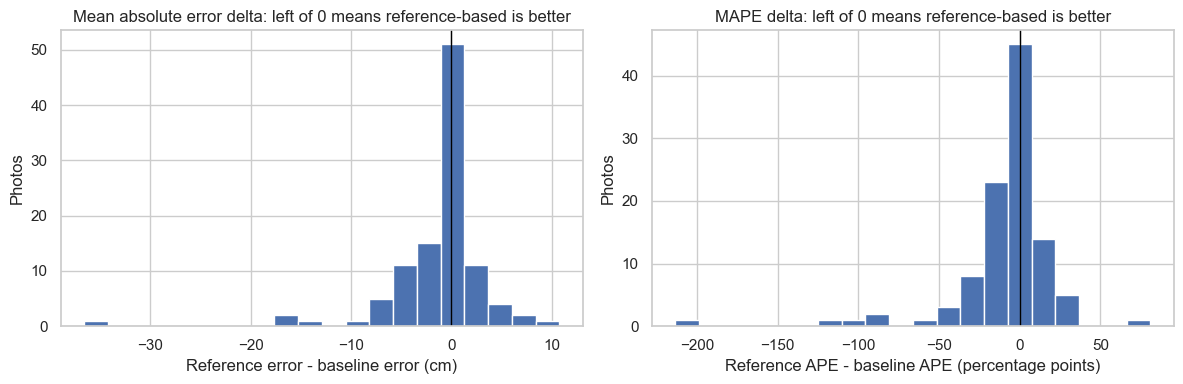

In [27]:
# Visualize the paired improvement distribution; mass left of zero favors reference-based estimation.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(eval_data["delta_mean_abs_error_cm"], bins=20, edgecolor="white")
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Mean absolute error delta: left of 0 means reference-based is better")
axes[0].set_xlabel("Reference error - baseline error (cm)")
axes[0].set_ylabel("Photos")

axes[1].hist(eval_data["delta_mean_ape_pct"], bins=20, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("MAPE delta: left of 0 means reference-based is better")
axes[1].set_xlabel("Reference APE - baseline APE (percentage points)")
axes[1].set_ylabel("Photos")

plt.tight_layout()

## Category-Level Results

The tables below show where reference-based estimation helps or hurts. `mean_delta_* < 0` means the reference method has lower error in that category.

The `paired_t_p_mape` and `wilcoxon_p_mape` columns test whether the paired reference-vs-baseline MAPE difference is significantly different from zero within that category. In other words, they answer: for photos in this category, is reference-based estimation significantly different from the VLM baseline? They do not test whether one category differs from another category.


In [28]:
# Apply the same paired comparison inside each category for apples-to-apples subgroup analysis.
def category_summary(df: pd.DataFrame, category: str) -> pd.DataFrame:
    rows = []
    for value, group in df.groupby(category, dropna=False):
        test_abs = paired_tests(group["delta_mean_abs_error_cm"])
        test_ape = paired_tests(group["delta_mean_ape_pct"])
        rows.append({
            "category": category,
            "value": value,
            "n": len(group),
            "baseline_mae_cm": group["baseline_mean_abs_error_cm"].mean(),
            "reference_mae_cm": group["reference_mean_abs_error_cm"].mean(),
            "mean_delta_mae_cm": test_abs["mean_delta"],
            "median_delta_mae_cm": test_abs["median_delta"],
            "delta_mae_ci_low": test_abs["mean_delta_ci_low"],
            "delta_mae_ci_high": test_abs["mean_delta_ci_high"],
            "baseline_mape_pct": group["baseline_mean_ape_pct"].mean(),
            "reference_mape_pct": group["reference_mean_ape_pct"].mean(),
            "mean_delta_mape_pct": test_ape["mean_delta"],
            "reference_better_rate": test_ape["reference_better_rate"],
            "paired_t_p_mape": test_ape["paired_t_p"],
            "wilcoxon_p_mape": test_ape["wilcoxon_p"],
        })
    return pd.DataFrame(rows).sort_values(["category", "mean_delta_mape_pct"])

primary_categories = [
    "dimension_knownness",
    "shape",
    "camera_pose",
    "reference_placement",
    "object_group",
]

# Adjust subgroup p-values to reduce false discoveries from many category tests.
def benjamini_hochberg(pvalues: pd.Series) -> pd.Series:
    p = pvalues.astype(float)
    adjusted = pd.Series(np.nan, index=p.index, dtype=float)
    valid = p.dropna().sort_values()
    m = len(valid)
    if m == 0:
        return adjusted
    ranked = valid * m / np.arange(1, m + 1)
    ranked = ranked.iloc[::-1].cummin().iloc[::-1].clip(upper=1.0)
    adjusted.loc[ranked.index] = ranked
    return adjusted

primary_summary = pd.concat([category_summary(eval_data, c) for c in primary_categories], ignore_index=True)
primary_summary["wilcoxon_q_mape"] = benjamini_hochberg(primary_summary["wilcoxon_p_mape"])
display(primary_summary.round(4))

,category,value,n,baseline_mae_cm,reference_mae_cm,mean_delta_mae_cm,median_delta_mae_cm,delta_mae_ci_low,delta_mae_ci_high,baseline_mape_pct,reference_mape_pct,mean_delta_mape_pct,reference_better_rate,paired_t_p_mape,wilcoxon_p_mape,wilcoxon_q_mape
0,dimension_knownness,unknown,47,5.9234,3.7685,-2.1549,-0.3184,-4.3578,-0.2878,33.0582,19.5216,-13.5365,0.6170,0.0313,0.0727,0.1349
1,dimension_knownness,known,58,1.9181,1.4574,-0.4607,-0.0437,-1.0697,0.2102,16.4402,11.7449,-4.6953,0.5517,0.1376,0.1015,0.1466
2,shape,irregular,53,5.4160,3.0376,-2.3785,-0.7287,-4.3487,-0.7651,35.2505,19.1470,-16.1035,0.7170,0.0086,0.0013,0.0087
3,shape,regular,52,1.9731,1.9357,-0.0374,0.0720,-0.8286,0.7693,12.2882,11.2294,-1.0588,0.4423,0.6297,0.8626,0.8647
4,camera_pose,topdown,35,3.9100,1.4652,-2.4448,-0.5957,-3.9134,-1.2250,25.8198,10.2132,-15.6066,0.7714,0.0010,0.0000,0.0005
5,camera_pose,rotated,36,3.8181,1.9288,-1.8893,-0.3764,-4.2819,-0.2702,22.6800,11.3394,-11.3406,0.6667,0.0752,0.0121,0.0314
6,camera_pose,tilted,34,3.3926,4.1450,0.7524,0.5612,-0.8004,2.2105,23.1497,24.5012,1.3515,0.2941,0.8190,0.0976,0.1466
7,reference_placement,near,52,4.1394,2.4452,-1.6942,-0.4668,-3.6149,-0.1436,25.9916,14.1917,-11.7999,0.6346,0.0321,0.0097,0.0314
8,reference_placement,far,53,3.2906,2.5377,-0.7529,-0.0185,-1.8070,0.2022,21.8057,16.2406,-5.5650,0.5283,0.1366,0.3979,0.5172
9,object_group,Irregular-Unknown,24,9.0521,4.3775,-4.6745,-1.6843,-8.6089,-1.5791,49.2738,21.7968,-27.4770,0.7500,0.0167,0.0048,0.0208


In [29]:
# Interaction categories test whether combinations such as irregular + tilted are especially hard.
interaction_categories = [
    "shape_x_camera",
    "knownness_x_camera",
    "shape_x_reference",
]

interaction_summary = pd.concat([category_summary(eval_data, c) for c in interaction_categories], ignore_index=True)
interaction_summary["wilcoxon_q_mape"] = benjamini_hochberg(interaction_summary["wilcoxon_p_mape"])
display(interaction_summary.round(4))

,category,value,n,baseline_mae_cm,reference_mae_cm,mean_delta_mae_cm,median_delta_mae_cm,delta_mae_ci_low,delta_mae_ci_high,baseline_mape_pct,reference_mape_pct,mean_delta_mape_pct,reference_better_rate,paired_t_p_mape,wilcoxon_p_mape,wilcoxon_q_mape
0,shape_x_camera,irregular + topdown,18,6.0722,1.7692,-4.3030,-3.5054,-6.6892,-2.2964,40.2684,12.8541,-27.4143,1.0000,0.0013,0.0000,0.0001
1,shape_x_camera,irregular + rotated,18,5.2889,2.4058,-2.8831,-0.5861,-7.2892,-0.2731,32.0123,13.9332,-18.0791,0.7222,0.1443,0.0090,0.0359
2,shape_x_camera,regular + rotated,18,2.3472,1.4518,-0.8955,-0.1703,-2.3524,0.4338,13.3476,8.7455,-4.6021,0.6111,0.2118,0.3247,0.4723
3,shape_x_camera,regular + topdown,17,1.6206,1.1433,-0.4773,-0.0221,-1.2349,0.1614,10.5214,7.4170,-3.1045,0.5294,0.2094,0.4874,0.5570
4,shape_x_camera,irregular + tilted,17,4.8559,5.0495,0.1936,0.5316,-2.5466,2.5570,33.3661,31.3306,-2.0355,0.4118,0.8529,0.4307,0.5301
5,shape_x_camera,regular + tilted,17,1.9294,3.2406,1.3112,0.5908,-0.2926,2.9392,12.9332,17.6718,4.7385,0.1765,0.3425,0.1324,0.2118
6,knownness_x_camera,unknown + topdown,15,6.1733,2.1560,-4.0173,-0.7785,-7.0298,-1.4568,36.2176,14.7001,-21.5175,0.7333,0.0292,0.0215,0.0689
7,knownness_x_camera,unknown + rotated,16,6.5875,3.1873,-3.4002,-0.8414,-8.4354,-0.0015,36.2063,16.5282,-19.6781,0.6875,0.1690,0.1167,0.2074
8,knownness_x_camera,known + topdown,20,2.2125,0.9471,-1.2654,-0.5707,-2.0721,-0.5216,18.0215,6.8480,-11.1735,0.8000,0.0062,0.0006,0.0047
9,knownness_x_camera,known + rotated,20,1.6025,0.9219,-0.6806,-0.2632,-1.4760,0.0022,11.8589,7.1883,-4.6706,0.6500,0.0395,0.0583,0.1521


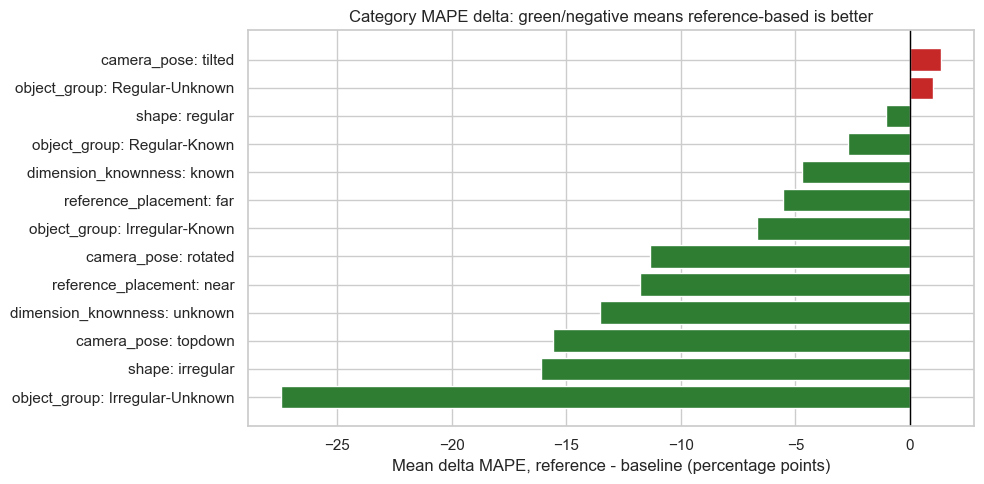

In [30]:
# Green bars indicate categories where reference-based estimation lowers MAPE on average.
plot_df = primary_summary.copy()
plot_df["label"] = plot_df["category"] + ": " + plot_df["value"].astype(str)
plot_df = plot_df.sort_values("mean_delta_mape_pct")

fig, ax = plt.subplots(figsize=(10, max(5, 0.35 * len(plot_df))))
colors = np.where(plot_df["mean_delta_mape_pct"] < 0, "#2e7d32", "#c62828")
ax.barh(plot_df["label"], plot_df["mean_delta_mape_pct"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Mean delta MAPE, reference - baseline (percentage points)")
ax.set_title("Category MAPE delta: green/negative means reference-based is better")
plt.tight_layout()

## Reference-Based Bias by Camera Pose

This section tests the observation that tilted images tend to make the reference-based method underestimate object size, while rotated images tend to make it overestimate. Unlike MAE/MAPE, these tests use signed percentage error: negative values mean the reference-based estimate is too small, and positive values mean it is too large.

In [31]:
def one_sample_signed_error_tests(values: pd.Series) -> pd.Series:
    """Test whether signed error is systematically different from zero."""
    values = values.dropna().astype(float)
    out = {
        "n": len(values),
        "mean_signed_pct": values.mean(),
        "median_signed_pct": values.median(),
        "std_signed_pct": values.std(ddof=1),
        "underestimate_rate": (values < 0).mean(),
        "overestimate_rate": (values > 0).mean(),
    }
    out["mean_signed_ci_low"], out["mean_signed_ci_high"] = bootstrap_ci(values)
    if stats is not None and len(values) >= 2:
        out["one_sample_t_p"] = stats.ttest_1samp(values, 0.0, nan_policy="omit").pvalue
        try:
            out["wilcoxon_signed_rank_p"] = stats.wilcoxon(values).pvalue
        except ValueError:
            out["wilcoxon_signed_rank_p"] = np.nan
    else:
        out["one_sample_t_p"] = np.nan
        out["wilcoxon_signed_rank_p"] = np.nan
    return pd.Series(out)

# Bias is evaluated for the average of the two dimensions and for each dimension separately.
bias_metrics = {
    "mean_of_length_width": "reference_mean_pe_pct",
    "length": "reference_length_pe_pct",
    "width": "reference_width_pe_pct",
}

bias_rows = []
for metric_name, column in bias_metrics.items():
    for camera_pose, group in eval_data.groupby("camera_pose"):
        tests = one_sample_signed_error_tests(group[column])
        bias_rows.append({"metric": metric_name, "camera_pose": camera_pose, **tests.to_dict()})

reference_camera_bias_summary = pd.DataFrame(bias_rows)
reference_camera_bias_summary["wilcoxon_q"] = benjamini_hochberg(reference_camera_bias_summary["wilcoxon_signed_rank_p"])
display(reference_camera_bias_summary.round(4))

,metric,camera_pose,n,mean_signed_pct,median_signed_pct,std_signed_pct,underestimate_rate,overestimate_rate,mean_signed_ci_low,mean_signed_ci_high,one_sample_t_p,wilcoxon_signed_rank_p,wilcoxon_q
0,mean_of_length_width,rotated,36.0,5.4389,6.3525,12.5613,0.2500,0.7500,1.3924,9.4352,0.0136,0.0121,0.0136
1,mean_of_length_width,tilted,34.0,-14.4255,-19.8836,27.8505,0.7059,0.2941,-22.8733,-4.2002,0.0048,0.0003,0.0014
2,mean_of_length_width,topdown,35.0,6.8909,4.9725,11.7846,0.3143,0.6857,3.1184,10.8167,0.0015,0.0015,0.0027
3,length,rotated,36.0,4.6908,7.6978,16.3653,0.3333,0.6667,-0.7718,9.6613,0.0943,0.0168,0.0168
4,length,tilted,34.0,-12.6875,-19.7243,32.6056,0.6765,0.3235,-22.6892,-0.7037,0.0299,0.0012,0.0027
5,length,topdown,35.0,7.5326,6.3141,13.1934,0.3143,0.6857,3.2216,11.8668,0.0018,0.0020,0.0029
6,width,rotated,36.0,6.1870,5.5827,10.7220,0.1667,0.8333,2.7832,9.7111,0.0014,0.0008,0.0023
7,width,tilted,34.0,-16.1635,-17.3740,25.3721,0.8235,0.1765,-24.0433,-7.1008,0.0008,0.0000,0.0003
8,width,topdown,35.0,6.2492,4.5900,11.3266,0.2857,0.7143,2.7298,10.0736,0.0025,0.0026,0.0033


In [32]:
from itertools import combinations

def pairwise_camera_bias_tests(df: pd.DataFrame, metric_name: str, column: str) -> pd.DataFrame:
    """Compare signed reference-based bias between camera poses."""
    rows = []
    for pose_a, pose_b in combinations(sorted(df["camera_pose"].dropna().unique()), 2):
        values_a = df.loc[df["camera_pose"] == pose_a, column].dropna().astype(float)
        values_b = df.loc[df["camera_pose"] == pose_b, column].dropna().astype(float)
        row = {
            "metric": metric_name,
            "pose_a": pose_a,
            "pose_b": pose_b,
            "n_a": len(values_a),
            "n_b": len(values_b),
            "mean_a": values_a.mean(),
            "mean_b": values_b.mean(),
            "mean_difference_a_minus_b": values_a.mean() - values_b.mean(),
        }
        if stats is not None and len(values_a) >= 2 and len(values_b) >= 2:
            row["welch_t_p"] = stats.ttest_ind(values_a, values_b, equal_var=False, nan_policy="omit").pvalue
            row["mann_whitney_p"] = stats.mannwhitneyu(values_a, values_b, alternative="two-sided").pvalue
        else:
            row["welch_t_p"] = np.nan
            row["mann_whitney_p"] = np.nan
        rows.append(row)
    return pd.DataFrame(rows)

pairwise_camera_bias = pd.concat(
    [pairwise_camera_bias_tests(eval_data, metric_name, column) for metric_name, column in bias_metrics.items()],
    ignore_index=True,
)
pairwise_camera_bias["mann_whitney_q"] = benjamini_hochberg(pairwise_camera_bias["mann_whitney_p"])
display(pairwise_camera_bias.round(4))

,metric,pose_a,pose_b,n_a,n_b,mean_a,mean_b,mean_difference_a_minus_b,welch_t_p,mann_whitney_p,mann_whitney_q
0,mean_of_length_width,rotated,tilted,36,34,5.4389,-14.4255,19.8644,0.0004,0.0000,0.0000
1,mean_of_length_width,rotated,topdown,36,35,5.4389,6.8909,-1.4520,0.6170,0.9130,0.9130
2,mean_of_length_width,tilted,topdown,34,35,-14.4255,6.8909,-21.3164,0.0002,0.0000,0.0000
3,length,rotated,tilted,36,34,4.6908,-12.6875,17.3784,0.0075,0.0005,0.0007
4,length,rotated,topdown,36,35,4.6908,7.5326,-2.8418,0.4228,0.7518,0.8458
5,length,tilted,topdown,34,35,-12.6875,7.5326,-20.2201,0.0016,0.0001,0.0001
6,width,rotated,tilted,36,34,6.1870,-16.1635,22.3505,0.0000,0.0000,0.0000
7,width,rotated,topdown,36,35,6.1870,6.2492,-0.0622,0.9811,0.6250,0.8035
8,width,tilted,topdown,34,35,-16.1635,6.2492,-22.4127,0.0000,0.0000,0.0000


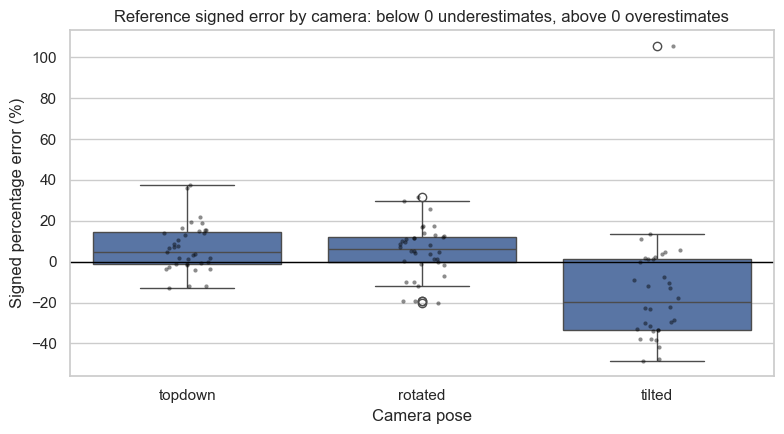

In [33]:
# Boxplots make the direction of the bias easy to see: below zero is smaller than ground truth.
fig, ax = plt.subplots(figsize=(8, 4.5))
if sns is not None:
    sns.boxplot(data=eval_data, x="camera_pose", y="reference_mean_pe_pct", order=["topdown", "rotated", "tilted"], ax=ax)
    sns.stripplot(data=eval_data, x="camera_pose", y="reference_mean_pe_pct", order=["topdown", "rotated", "tilted"], color="black", alpha=0.45, size=3, ax=ax)
else:
    grouped = [eval_data.loc[eval_data["camera_pose"] == pose, "reference_mean_pe_pct"].dropna() for pose in ["topdown", "rotated", "tilted"]]
    ax.boxplot(grouped, labels=["topdown", "rotated", "tilted"])
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Reference signed error by camera: below 0 underestimates, above 0 overestimates")
ax.set_xlabel("Camera pose")
ax.set_ylabel("Signed percentage error (%)")
plt.tight_layout()

## Dimension-Specific Analysis

This section checks whether one method is stronger for length than width.

In [34]:
# Analyze length and width separately in case one dimension drives the overall result.
dimension_rows = []
for dim in ["length", "width"]:
    delta_abs = eval_data[f"reference_{dim}_abs_error_cm"] - eval_data[f"baseline_{dim}_abs_error_cm"]
    delta_ape = eval_data[f"reference_{dim}_ape_pct"] - eval_data[f"baseline_{dim}_ape_pct"]
    test_abs = paired_tests(delta_abs)
    test_ape = paired_tests(delta_ape)
    dimension_rows.append({
        "dimension": dim,
        "baseline_mae_cm": eval_data[f"baseline_{dim}_abs_error_cm"].mean(),
        "reference_mae_cm": eval_data[f"reference_{dim}_abs_error_cm"].mean(),
        "mean_delta_mae_cm": test_abs["mean_delta"],
        "baseline_mape_pct": eval_data[f"baseline_{dim}_ape_pct"].mean(),
        "reference_mape_pct": eval_data[f"reference_{dim}_ape_pct"].mean(),
        "mean_delta_mape_pct": test_ape["mean_delta"],
        "reference_better_rate": test_ape["reference_better_rate"],
        "paired_t_p_mape": test_ape["paired_t_p"],
        "wilcoxon_p_mape": test_ape["wilcoxon_p"],
    })

dimension_summary = pd.DataFrame(dimension_rows)
display(dimension_summary.round(4))

,dimension,baseline_mae_cm,reference_mae_cm,mean_delta_mae_cm,baseline_mape_pct,reference_mape_pct,mean_delta_mape_pct,reference_better_rate,paired_t_p_mape,wilcoxon_p_mape
0,length,4.6067,3.3175,-1.2892,23.7070,16.9282,-6.7789,0.5238,0.0280,0.1445
1,width,2.8152,1.6663,-1.1489,24.0503,13.5236,-10.5267,0.6095,0.0046,0.0028


## Outliers and Failure Cases

The largest positive deltas are cases where reference-based estimation is much worse. The largest negative deltas are cases where it is much better.

In [35]:
# Inspect individual failure cases after aggregate statistics to identify practical error modes.
cols = [
    "Photo ID", "Target Name", "dimension_knownness", "shape", "camera_pose", "reference_placement",
    "truth_length_cm", "truth_width_cm",
    "baseline_length_cm", "baseline_width_cm", "baseline_mean_ape_pct",
    "reference_length_cm", "reference_width_cm", "reference_mean_ape_pct",
    "delta_mean_ape_pct",
]

print("Reference-based much worse than baseline:")
display(eval_data.sort_values("delta_mean_ape_pct", ascending=False)[cols].head(10).round(3))

print("Reference-based much better than baseline:")
display(eval_data.sort_values("delta_mean_ape_pct", ascending=True)[cols].head(10).round(3))

Reference-based much worse than baseline:


,Photo ID,Target Name,dimension_knownness,shape,camera_pose,reference_placement,truth_length_cm,truth_width_cm,baseline_length_cm,baseline_width_cm,baseline_mean_ape_pct,reference_length_cm,reference_width_cm,reference_mean_ape_pct,delta_mean_ape_pct
70,12_SOFTSOAPLI_TILT45_NEAR,Softsoap Liquid Hand Soap,known,irregular,tilted,near,17.0,9.0,10.5,8.0,24.673,38.223,16.757,105.514,80.841
41,07_BOOK_TILT45_FAR,Book,unknown,regular,tilted,far,28.6,21.0,27.0,21.0,2.797,20.608,10.731,38.422,35.625
40,07_BOOK_TILT45_NEAR,Book,unknown,regular,tilted,near,28.6,21.0,28.0,21.0,1.049,23.142,12.620,29.495,28.446
83,14_ALIENWAREM_TILT45_FAR,Alienware Mouse AW610M,known,irregular,tilted,far,13.0,8.0,10.0,6.5,20.913,6.254,4.528,47.648,26.734
59,10_IPAD_TILT45_FAR,iPad,unknown,regular,tilted,far,24.7,19.0,18.0,18.0,16.194,13.977,11.299,41.971,25.777
71,12_SOFTSOAPLI_TILT45_FAR,Softsoap Liquid Hand Soap,known,irregular,tilted,far,17.0,9.0,18.0,10.5,11.275,12.550,5.316,33.553,22.279
119,20_BOWL_TILT45_FAR,Bowl,unknown,irregular,tilted,far,20.0,20.0,20.0,13.0,17.500,14.746,10.080,37.933,20.433
65,11_AIRPODSCAS_TILT45_FAR,AirPods case,known,irregular,tilted,far,6.5,5.0,7.0,6.0,13.846,3.940,3.609,33.603,19.756
38,07_BOOK_ROT45_NEAR,Book,unknown,regular,rotated,near,28.6,21.0,28.0,21.0,1.049,21.547,17.648,20.311,19.262
53,09_TOOTHPASTE_TILT45_FAR,Toothpaste Box,unknown,regular,tilted,far,22.0,5.0,17.6,5.3,13.000,13.361,3.970,29.932,16.932


Reference-based much better than baseline:


,Photo ID,Target Name,dimension_knownness,shape,camera_pose,reference_placement,truth_length_cm,truth_width_cm,baseline_length_cm,baseline_width_cm,baseline_mean_ape_pct,reference_length_cm,reference_width_cm,reference_mean_ape_pct,delta_mean_ape_pct
104,18_PEANUTMASS_ROT45_NEAR,Peanut Massage Ball,unknown,irregular,rotated,near,23.5,12.0,73.0,42.0,230.319,28.144,13.720,17.047,-213.272
77,13_AUDICARKEY_TILT45_FAR,Audi Car Key,known,irregular,tilted,far,7.5,3.1,18.0,8.0,149.032,4.910,2.235,31.217,-117.816
103,18_PEANUTMASS_TD_FAR,Peanut Massage Ball,unknown,irregular,topdown,far,23.5,12.0,44.0,31.0,122.784,27.974,13.413,15.407,-107.377
106,18_PEANUTMASS_TILT45_NEAR,Peanut Massage Ball,unknown,irregular,tilted,near,23.5,12.0,48.0,24.0,102.128,18.723,11.997,10.174,-91.954
102,18_PEANUTMASS_TD_NEAR,Peanut Massage Ball,unknown,irregular,topdown,near,23.5,12.0,44.0,28.0,110.284,28.813,13.948,19.422,-90.862
60,11_AIRPODSCAS_TD_NEAR,AirPods case,known,irregular,topdown,near,6.5,5.0,12.0,8.0,72.308,7.097,5.240,6.997,-65.310
105,18_PEANUTMASS_ROT45_FAR,Peanut Massage Ball,unknown,irregular,rotated,far,23.5,12.0,34.0,20.0,55.674,26.979,13.134,12.127,-43.547
57,10_IPAD_ROT45_FAR,iPad,unknown,regular,rotated,far,24.7,19.0,38.0,27.0,47.976,26.508,20.414,7.379,-40.597
47,08_BLUETOOTHA_TILT45_FAR,Bluetooth audio,unknown,regular,tilted,far,15.5,7.0,25.5,10.5,57.258,11.940,6.116,17.795,-39.463
114,20_BOWL_TD_NEAR,Bowl,unknown,irregular,topdown,near,20.0,20.0,31.0,29.0,50.000,23.175,22.935,15.275,-34.725


## Export Tables


In [36]:
# Save clean CSV tables for the report and for any follow-up plotting outside the notebook.
EVAL_OUT_DIR = REPO_ROOT / "results" / "evaluation"
EVAL_OUT_DIR.mkdir(parents=True, exist_ok=True)

eval_data.to_csv(EVAL_OUT_DIR / "paired_photo_errors.csv", index=False)
overall.to_csv(EVAL_OUT_DIR / "overall_paired_tests.csv")
primary_summary.to_csv(EVAL_OUT_DIR / "primary_category_summary.csv", index=False)
interaction_summary.to_csv(EVAL_OUT_DIR / "interaction_category_summary.csv", index=False)
reference_camera_bias_summary.to_csv(EVAL_OUT_DIR / "reference_camera_bias_summary.csv", index=False)
pairwise_camera_bias.to_csv(EVAL_OUT_DIR / "pairwise_camera_bias_tests.csv", index=False)
dimension_summary.to_csv(EVAL_OUT_DIR / "dimension_summary.csv", index=False)

print(f"Wrote evaluation tables to {EVAL_OUT_DIR.relative_to(REPO_ROOT)}")

Wrote evaluation tables to results/evaluation


## Report Notes Template
1. Overall: report whether the reference-based method has lower mean absolute error and lower mean absolute percentage error than the VLM baseline.
2. Significance: report the paired t-test and Wilcoxon p-values for `delta_mean_ape_pct`.
3. Practical effect: report the mean delta and its bootstrap 95% CI. A negative interval fully below zero supports reference-based improvement.
4. Category effects: discuss categories where reference-based estimation helps most and categories where it fails or is less stable.
5. Failure cases: inspect the top outliers and relate them to object shape, camera pose, and reference placement.